In [112]:
import os
import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, 
    SplineTransformer, 
    QuantileTransformer, 
    RobustScaler,
    PolynomialFeatures,
    KBinsDiscretizer,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import GradientBoostingClassifier

In [113]:
TABLE_NAME = "users_churn"

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000


# =========================
# EDA
# =========================

EDA_EXPERIMENT_NAME = "eda_churn"
EDA_RUN_NAME = "eda"
ASSETS_DIR = "assets"


# =========================
# PREPROCESSING
# =========================

PREPROCESSING_EXPERIMENT_NAME = "preprocessing"
PREPROCESSING_RUN_NAME = "preprocessing"

REGISTRY_MODEL_NAME = "baseline_version_1"

In [114]:
os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

sns.set_style("white")
sns.set_theme(style="whitegrid")

mlflow.set_tracking_uri(
    f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
)

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

MLflow Tracking URI:
http://127.0.0.1:5000


In [115]:
# ============================================================
# 1. Настройка S3 / Yandex Cloud
# ============================================================

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")


# ============================================================
# 2. Название эксперимента
# ============================================================

EXPERIMENT_NAME = "churn_version_2"


# ============================================================
# 3. Проверяем существующие эксперименты
# ============================================================

print("\nСуществующие эксперименты:")

experiments = mlflow.search_experiments()

for exp in experiments:
    print(f"id={exp.experiment_id} | name={exp.name}")


# ============================================================
# 4. Получаем эксперимент
#    Если его нет — создаём
# ============================================================

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    print(f"\nЭксперимент '{EXPERIMENT_NAME}' не найден.")
    print("Создаём новый эксперимент...")

    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME
    )

    print(f"Эксперимент создан. ID = {experiment_id}")

else:
    experiment_id = experiment.experiment_id

    print(
        f"\nЭксперимент '{EXPERIMENT_NAME}' уже существует. "
        f"ID = {experiment_id}"
    )


Существующие эксперименты:
id=4 | name=churn_version_2
id=3 | name=eda_churn
id=2 | name=churn_fio_final
id=1 | name=churn_fio

Эксперимент 'churn_version_2' уже существует. ID = 4


In [116]:
# ============================================================
# 7. НАСТРОЙКИ RUN
# ============================================================

RUN_NAME = "assets_upload"
ASSETS_DIR = "./assets"


# ============================================================
# 8. ЗАПУСКАЕМ RUN
# ============================================================

with mlflow.start_run(
    run_name=RUN_NAME,
    experiment_id=experiment_id
) as run:

    run_id = run.info.run_id

    print("\nRun запущен.")
    print("run_id:", run_id)

    # ========================================================
    # 9. ЗАГРУЖАЕМ ВСЕ ФАЙЛЫ ИЗ ASSETS В MLflow
    # ========================================================

    if os.path.exists(ASSETS_DIR):

        files = os.listdir(ASSETS_DIR)

        if len(files) > 0:

            print("\nЗагружаем файлы из папки assets:")

            for file_name in files:
                print(" -", file_name)

            mlflow.log_artifacts(ASSETS_DIR)

            print("\nФайлы успешно загружены в MLflow.")

        else:
            print("\nПапка assets пустая.")
            print("Загружать в MLflow пока нечего.")

    else:
        print(f"\nПапка {ASSETS_DIR} не найдена.")


# ============================================================
# 10. ФИНАЛЬНЫЙ РЕЗУЛЬТАТ
# ============================================================

print("\n" + "=" * 60)
print("ГОТОВО")
print("=" * 60)

print("Experiment name:", EXPERIMENT_NAME)
print("Experiment ID:", experiment_id)
print("Run name:", RUN_NAME)
print("Run ID:", run_id)

print("=" * 60)


Run запущен.
run_id: 0469983181d84e619a3572169ab8a748

Загружаем файлы из папки assets:
 - cat_features_2_binary_heatmap.png
 - chargest_by_target_dist.png
 - target_count.png
 - target_by_date.png
 - charges_by_date.png
 - cat_features_1.png



Файлы успешно загружены в MLflow.

ГОТОВО
Experiment name: churn_version_2
Experiment ID: 4
Run name: assets_upload
Run ID: 0469983181d84e619a3572169ab8a748


In [117]:
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write"
}

postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

# Проверяем первые строки
display(df.head(2))

# Выбираем категориальные признаки
obj_df = df.select_dtypes(include="object")

display(obj_df.head(2))

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,5768,8498-XXGWA,2014-09-01,NaT,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,Yes,No,Yes,No,No,No,Female,0,Yes,No,No,0
1,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,None,0


,customer_id,type,paperless_billing,payment_method,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,partner,dependents,multiple_lines
0,8498-XXGWA,Month-to-month,Yes,Mailed check,DSL,Yes,No,Yes,No,No,No,Female,Yes,No,No
1,7590-VHVEG,Month-to-month,Yes,Electronic check,DSL,No,Yes,No,No,No,No,Female,Yes,No,None


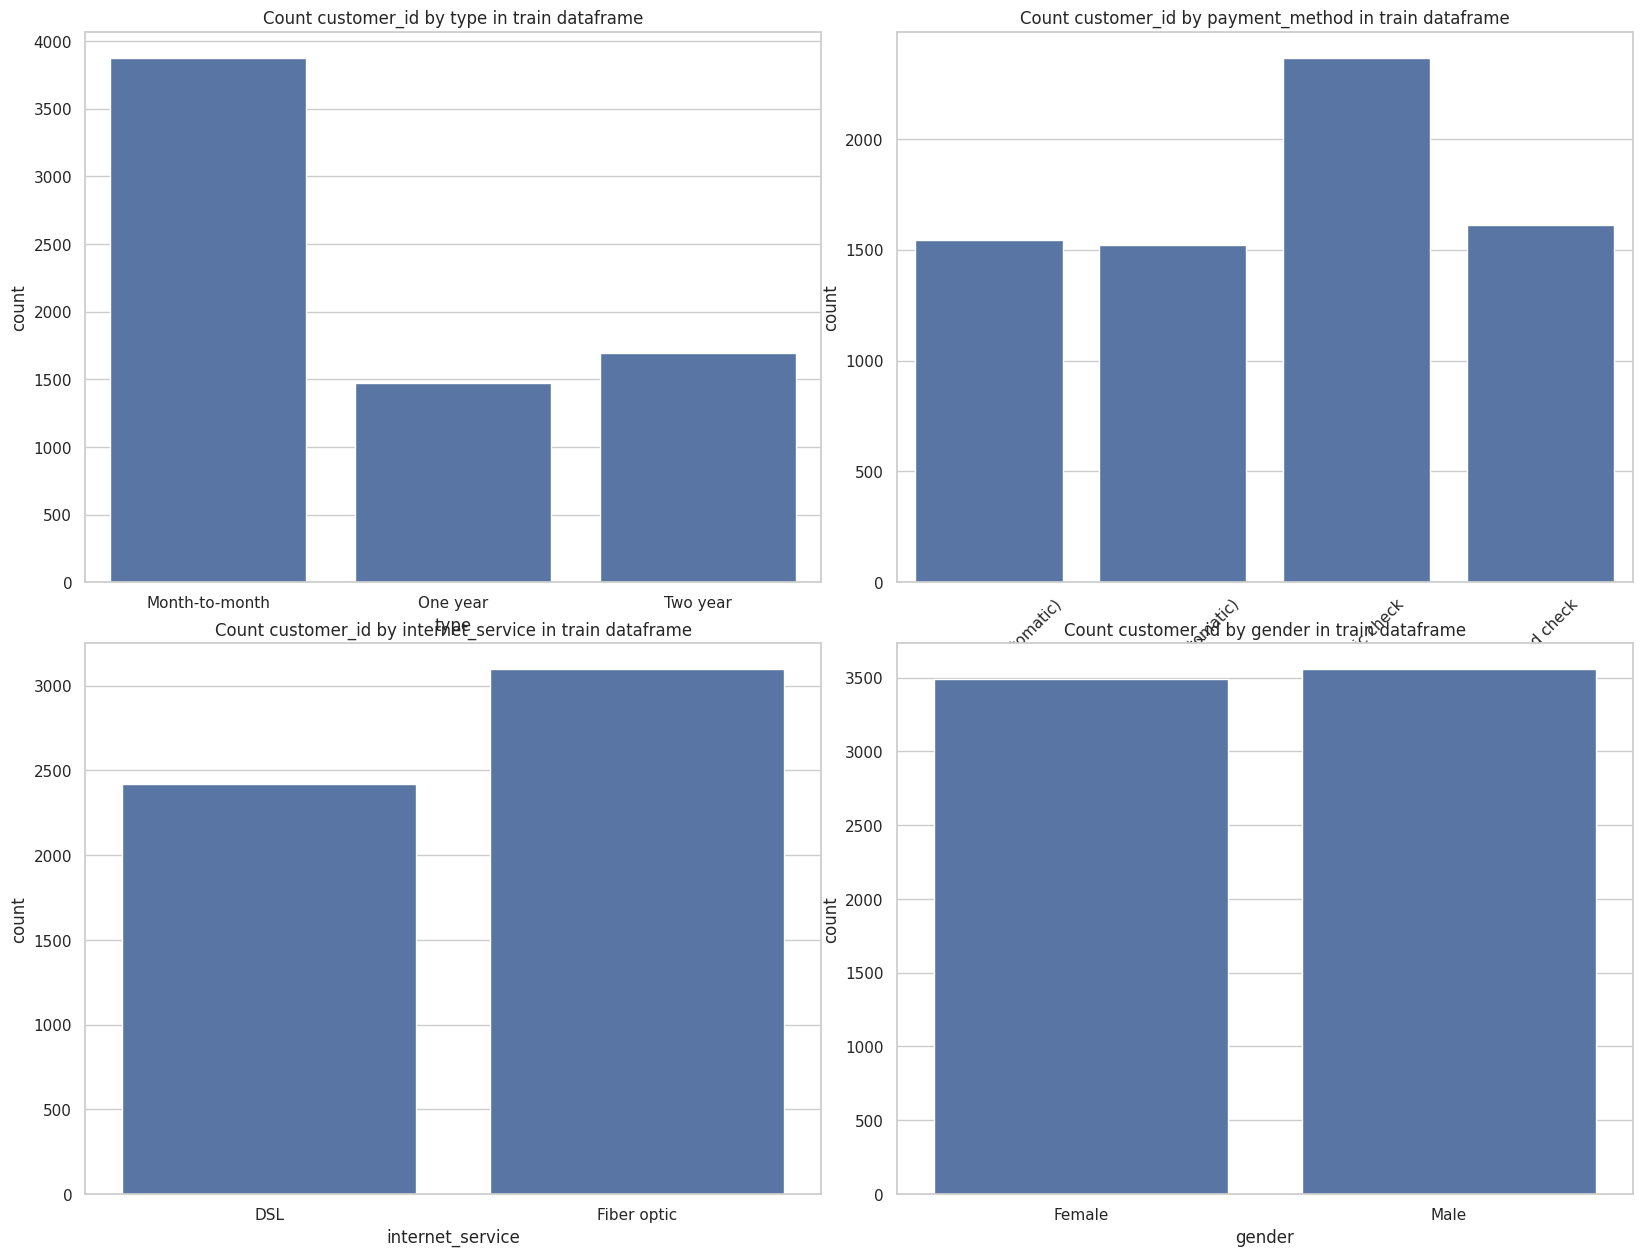

In [118]:
fig, axs = plt.subplots(2, 2)

fig.set_size_inches(16.5, 12.5, forward=True)
fig.tight_layout(pad=1.6)


x = "type"
y = "customer_id"

agg_df = df.groupby(x)[y].nunique().reset_index(name="count")

sns.barplot(data=agg_df, x=x, y="count", ax=axs[0, 0])
axs[0, 0].set_title(f"Count {y} by {x} in train dataframe")


x = "payment_method"
y = "customer_id"

agg_df = df.groupby(x)[y].nunique().reset_index(name="count")

sns.barplot(data=agg_df, x=x, y="count", ax=axs[0, 1])
axs[0, 1].set_title(f"Count {y} by {x} in train dataframe")
axs[0, 1].tick_params(axis="x", rotation=45)


x = "internet_service"
y = "customer_id"

agg_df = df.groupby(x)[y].nunique().reset_index(name="count")

sns.barplot(data=agg_df, x=x, y="count", ax=axs[1, 0])
axs[1, 0].set_title(f"Count {y} by {x} in train dataframe")


x = "gender"
y = "customer_id"

agg_df = df.groupby(x)[y].nunique().reset_index(name="count")

sns.barplot(data=agg_df, x=x, y="count", ax=axs[1, 1])
axs[1, 1].set_title(f"Count {y} by {x} in train dataframe")


plt.savefig(os.path.join(ASSETS_DIR, "cat_features_1"))


In [119]:
x = "customer_id"

binary_columns = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]

stat = (
    df[binary_columns + [x]]
    .melt(id_vars=x, value_vars=binary_columns)
    .query("value == 1")
    .groupby("variable")[x]
    .nunique()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(stat)

         variable  count
0  senior_citizen   1142


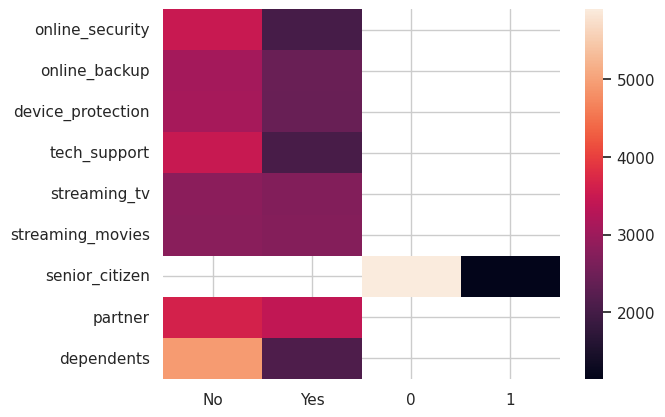

In [120]:
heat_df = df[binary_columns].apply(pd.Series.value_counts).T

sns.heatmap(heat_df)

plt.savefig(os.path.join(ASSETS_DIR, 'cat_features_2_binary_heatmap'))

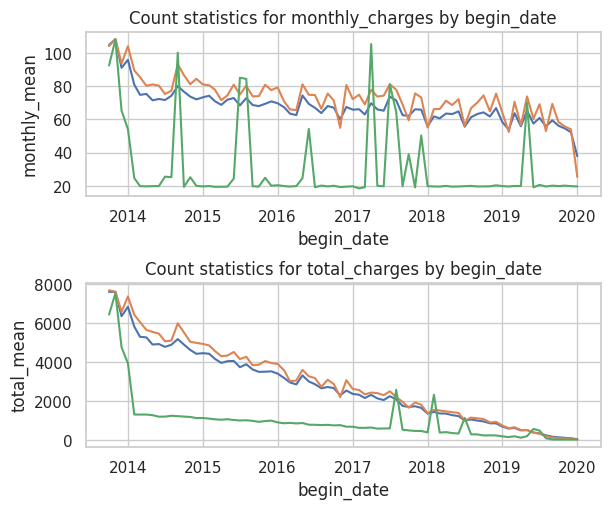

In [121]:
# инициализация переменной для названия колонки
x = "begin_date"

# список колонок, для которых будут вычисляться статистики
charges_columns = [
    "monthly_charges",
    "total_charges",
]

# удаление пустых колонок для посчёта медианного значения
df.dropna(subset=charges_columns, how='any', inplace=True)

# список статистик, которые будут вычисляться для каждой группы
stats = ["mean", "median", lambda x: x.mode().iloc[0]]

# группировка данных по дате начала и агрегация статистик для ежемесячных платежей
charges_monthly_agg = (
    df[[x] + [charges_columns[0]]]
    .groupby([x])
    .agg(stats)
    .reset_index()
)

# удаление верхнего уровня индекса колонок
charges_monthly_agg.columns = charges_monthly_agg.columns.droplevel()

# переименование колонок
charges_monthly_agg.columns = [
    x,
    "monthly_mean",
    "monthly_median",
    "monthly_mode"
]

# аналогично для общих платежей
charges_total_agg = (
    df[[x] + [charges_columns[1]]]
    .groupby([x])
    .agg(stats)
    .reset_index()
)

charges_total_agg.columns = charges_total_agg.columns.droplevel()

charges_total_agg.columns = [
    x,
    "total_mean",
    "total_median",
    "total_mode"
]

# создание объекта для отображения графиков
fig, axs = plt.subplots(2, 1)

# настройка отступов между графиками
fig.tight_layout(pad=2.5)

# установка размера фигуры
fig.set_size_inches(6.5, 5.5, forward=True)


# ===== monthly_charges =====

sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y='monthly_mean')

sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y='monthly_median')

sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y='monthly_mode')

axs[0].set_title(
    f"Count statistics for {charges_columns[0]} by {x}"
)


# ===== total_charges =====

sns.lineplot(charges_total_agg, ax=axs[1], x=x, y='total_mean')

sns.lineplot(charges_total_agg, ax=axs[1], x=x, y='total_median')

sns.lineplot(charges_total_agg, ax=axs[1], x=x, y='total_mode')

axs[1].set_title(
    f"Count statistics for {charges_columns[1]} by {x}"
)


# сохранение графика в файл
plt.savefig(os.path.join(ASSETS_DIR, 'charges_by_date'))

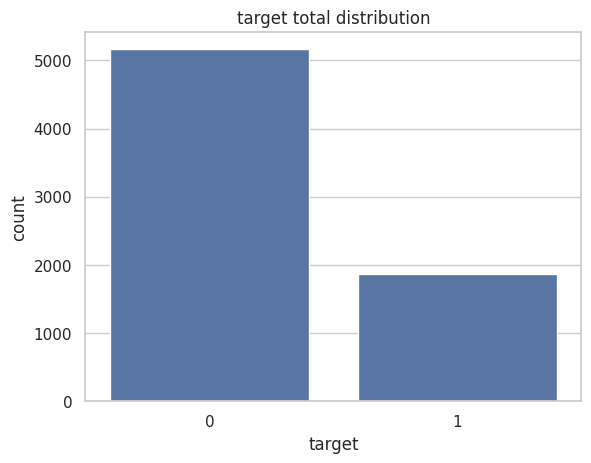

In [122]:
# директория для сохранения картинок
ASSETS_DIR = "assets"

# название целевой переменной
x = "target"

# подсчёт количества каждого уникального значения
target_agg = (
    df[x]
    .value_counts()
    .reset_index()
)

# переименовываем столбцы
target_agg.columns = [x, "count"]

# построение графика
sns.barplot(data=target_agg, x=x, y="count")

# заголовок
plt.title(f"{x} total distribution")

# сохранение графика
plt.savefig(os.path.join(ASSETS_DIR, "target_count"))
plt.show()

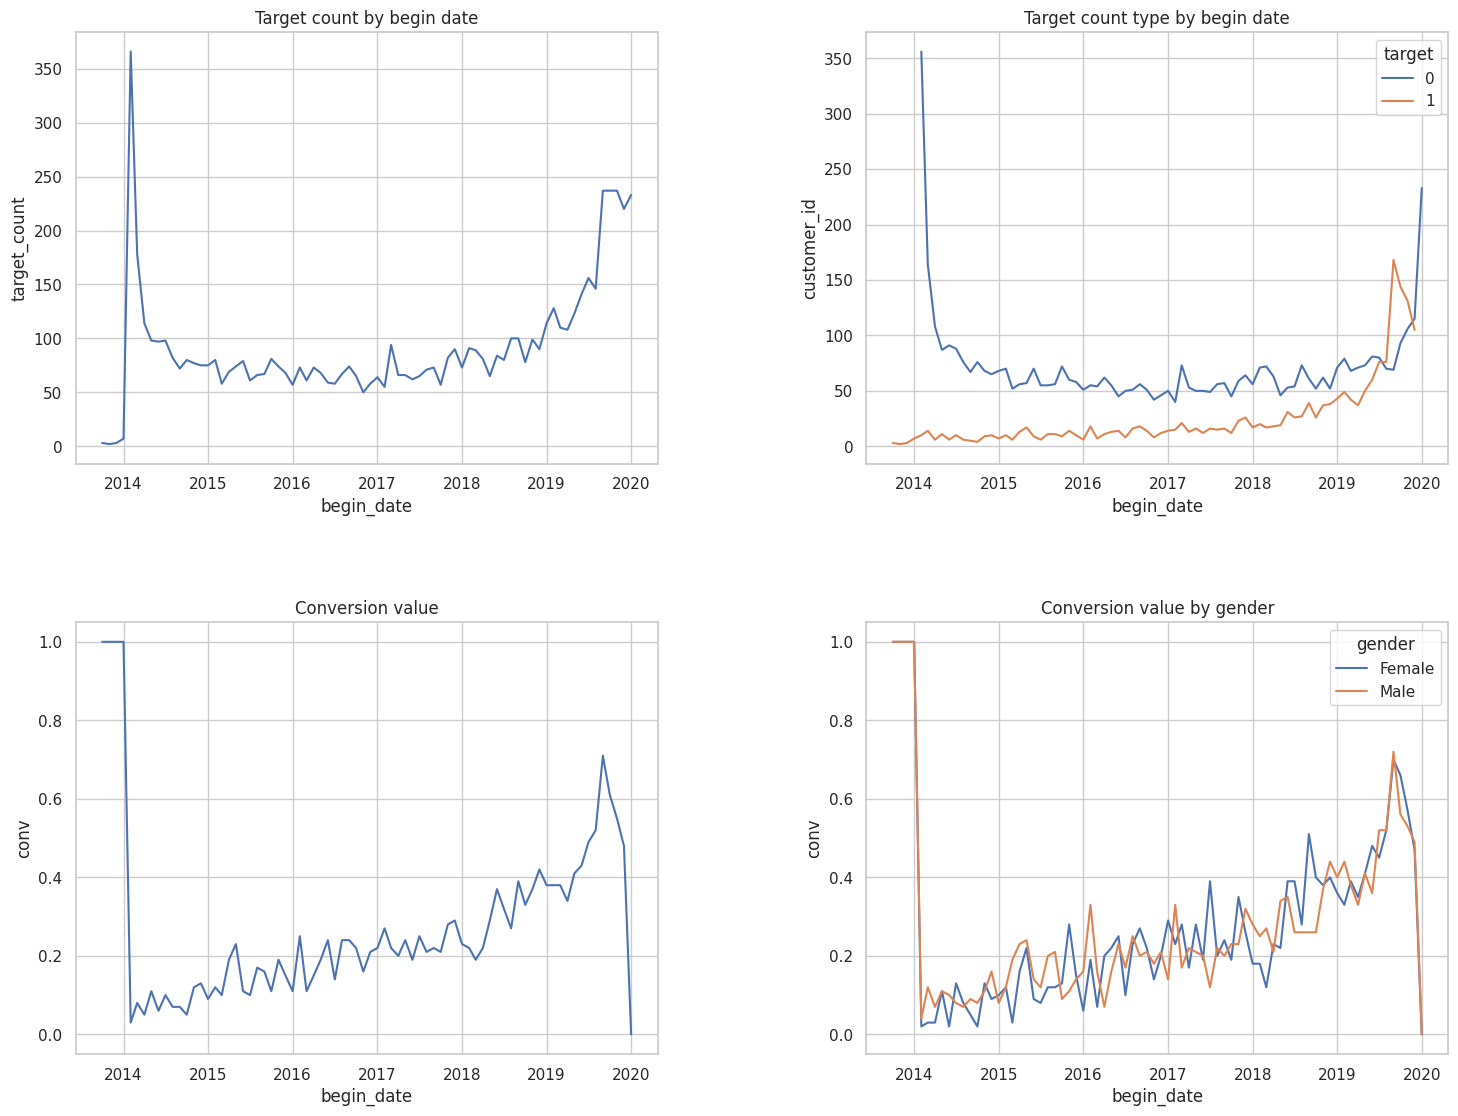

In [123]:
# установка переменных для анализа
x = "begin_date"
target = "target"

# определение статистики для агрегации
stat = ["count"]

# агрегация количества целей по датам начала с последующим сбросом индекса
target_agg_by_date = df[[x, target]].groupby([x]).agg(stat).reset_index()
# удаление мультиуровневости заголовков после агрегации и переименование для удобства
target_agg_by_date.columns = target_agg_by_date.columns.droplevel()
target_agg_by_date.columns = [x, "target_count"]

# подсчёт количества клиентов для каждого значения цели по датам
target_agg = df[[x, target, 'customer_id']].groupby([x, target]).count().reset_index()

# расчёт суммы и количества для конверсии по датам
conversion_agg = df[[x, target]].groupby([x])['target'].agg(['sum', 'count']).reset_index()

# вычисление коэффициента конверсии и округление до двух знаков
conversion_agg['conv'] = (conversion_agg['sum'] / conversion_agg['count']).round(2)
# аналогичный расчет конверсии, но с дополнительным разделением по полу
conversion_agg_gender = df[[x, target, 'gender']].groupby([x, 'gender'])[target].agg(['sum', 'count']).reset_index()

conversion_agg_gender['conv'] = (conversion_agg_gender['sum'] / conversion_agg_gender['count']).round(2)
# инициализация фигуры для отображения нескольких графиков
fig, axs = plt.subplots(2, 2)
fig.tight_layout(pad=1.6)  # настройка отступов между подграфиками
fig.set_size_inches(16.5, 12.5, forward=True)  # установка размера фигуры

# визуализация общего количества целей по датам начала
sns.lineplot(
    data=target_agg_by_date,
    x=x,
    y="target_count",
    ax=axs[0, 0]
)
axs[0, 0].set_title("Target count by begin date")

# визуализация количества клиентов для каждого типа цели по датам
sns.lineplot(
    data=target_agg,
    x=x,
    y="customer_id",
    hue=target,
    ax=axs[0, 1]
)
axs[0, 1].set_title("Target count type by begin date")

# визуализация коэффициента конверсии по датам
sns.lineplot(
    data=conversion_agg,
    x=x,
    y="conv",
    ax=axs[1, 0]
)
axs[1, 0].set_title("Conversion value")

# визуализация коэффициента конверсии по датам с разделением по полу
sns.lineplot(
    data=conversion_agg_gender,
    x=x,
    y="conv",
    hue="gender",
    ax=axs[1, 1]
)
axs[1, 1].set_title("Conversion value by gender")

# сохранение визуализации в файл
plt.savefig(os.path.join(ASSETS_DIR, 'target_by_date'))

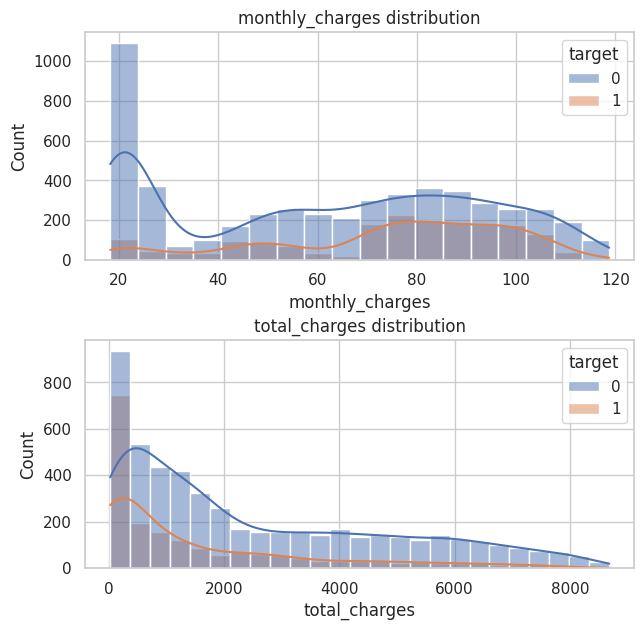

In [124]:
# определение списка столбцов с данными о платежах и целевой переменной
charges = ["monthly_charges", "total_charges"]
target = "target"

# инициализация фигуры для отображения гистограмм
fig, axs = plt.subplots(2, 1)
fig.tight_layout(pad=1.5)  # настройка отступов между подграфиками
fig.set_size_inches(6.5, 6.5, forward=True)  # установка размера фигуры

# визуализация распределения ежемесячных платежей с разделением по целевой переменной
sns.histplot(
    data=df,
    x=charges[0],
    hue=target,
    kde=True,
    ax=axs[0]
)
axs[0].set_title(f"{charges[0]} distribution")

# визуализация распределения общих платежей с разделением по целевой переменной
sns.histplot(
    data=df,
    x=charges[1],
    hue=target,
    kde=True,
    ax=axs[1]
)
axs[1].set_title(f"{charges[1]} distribution")

# сохранение фигуры с гистограммами в файл
plt.savefig(os.path.join(ASSETS_DIR, 'chargest_by_target_dist'))

## Работа с признаками.

In [125]:
# =========================================================
# Настройки
# =========================================================

num_columns = ["monthly_charges", "total_charges"]

n_knots = 3
degree_spline = 4

n_quantiles = 100

degree = 3

n_bins = 5
encode = "ordinal"
strategy = "uniform"
subsample = None


# =========================================================
# Создаём DataFrame с исходными признаками
# =========================================================

num_df = df[num_columns].copy()


# =========================================================
# SplineTransformer
# =========================================================

encoder_spl = SplineTransformer(
    n_knots=n_knots,
    degree=degree_spline
)

encoded_features = encoder_spl.fit_transform(
    df[num_columns].to_numpy()
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder_spl.get_feature_names_out(num_columns),
    index=df.index
)

num_df = pd.concat(
    [num_df, encoded_df],
    axis=1
)


# =========================================================
# QuantileTransformer
# =========================================================

encoder_q = QuantileTransformer(
    n_quantiles=n_quantiles
)

encoded_features = encoder_q.fit_transform(
    df[num_columns].to_numpy()
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder_q.get_feature_names_out(num_columns),
    index=df.index
)

encoded_df.columns = [
    col + f"_q_{n_quantiles}"
    for col in num_columns
]

num_df = pd.concat(
    [num_df, encoded_df],
    axis=1
)


# =========================================================
# RobustScaler
# =========================================================

encoder_rb = RobustScaler()

encoded_features = encoder_rb.fit_transform(
    df[num_columns].to_numpy()
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder_rb.get_feature_names_out(num_columns),
    index=df.index
)

encoded_df.columns = [
    col + "_robust"
    for col in num_columns
]

num_df = pd.concat(
    [num_df, encoded_df],
    axis=1
)


# =========================================================
# PolynomialFeatures
# =========================================================

encoder_pol = PolynomialFeatures(
    degree=degree
)

encoded_features = encoder_pol.fit_transform(
    df[num_columns].to_numpy()
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder_pol.get_feature_names_out(num_columns),
    index=df.index
)

# Убираем:
# 1. константу
# 2. исходные признаки первой степени
#
# Для двух признаков и degree=3
# останутся 7 полиномиальных признаков:
#
# x1^2
# x1*x2
# x2^2
# x1^3
# x1^2*x2
# x1*x2^2
# x2^3

encoded_df = encoded_df.iloc[:, 1 + len(num_columns):]

num_df = pd.concat(
    [num_df, encoded_df],
    axis=1
)


# =========================================================
# KBinsDiscretizer
# =========================================================

encoder_kbd = KBinsDiscretizer(
    n_bins=n_bins,
    encode=encode,
    strategy=strategy,
    subsample=subsample
)

encoded_features = encoder_kbd.fit_transform(
    df[num_columns].to_numpy()
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder_kbd.get_feature_names_out(num_columns),
    index=df.index
)

encoded_df.columns = [
    col + "_bin"
    for col in num_columns
]

num_df = pd.concat(
    [num_df, encoded_df],
    axis=1
)

display(num_df.head(2))

,monthly_charges,total_charges,monthly_charges_sp_0,monthly_charges_sp_1,monthly_charges_sp_2,monthly_charges_sp_3,monthly_charges_sp_4,monthly_charges_sp_5,total_charges_sp_0,total_charges_sp_1,total_charges_sp_2,total_charges_sp_3,total_charges_sp_4,total_charges_sp_5,monthly_charges_q_100,total_charges_q_100,monthly_charges_robust,total_charges_robust,monthly_charges^2,monthly_charges total_charges,total_charges^2,monthly_charges^3,monthly_charges^2 total_charges,monthly_charges total_charges^2,total_charges^3,monthly_charges_bin,total_charges_bin
0,55.15,3673.15,0.000208,0.105886,0.565393,0.316398,0.012116,0.0,0.000025,0.074443,0.528742,0.375710,2.108019e-02,0.0,0.375180,0.741008,-0.280055,0.670640,3041.5225,202574.2225,1.349203e+07,167739.965875,1.117197e+07,7.440855e+08,4.955825e+10,1.0,2.0
1,29.85,29.85,0.014583,0.335266,0.554993,0.095040,0.000118,0.0,0.041243,0.457057,0.459607,0.042093,1.762313e-12,0.0,0.232496,0.027400,-0.746200,-0.403038,891.0225,891.0225,8.910225e+02,26597.021625,2.659702e+04,2.659702e+04,2.659702e+04,0.0,0.0


In [126]:
# Числовые признаки
num_columns = [
    "monthly_charges",
    "total_charges"
]

# Категориальные признаки
cat_columns = [
    "type",
    "paperless_billing",
    "payment_method",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "gender",
    "partner",
    "dependents",
    "multiple_lines"
]

# One-Hot Encoding
encoder_oh = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Обработка числовых признаков
numeric_transformer = ColumnTransformer(
    transformers=[
        ("spl", encoder_spl, num_columns),
        ("q", encoder_q, num_columns),
        ("rb", encoder_rb, num_columns),
        ("pol", encoder_pol, num_columns),
        ("kbd", encoder_kbd, num_columns)
    ]
)

# Обработка категориальных признаков
categorical_transformer = Pipeline(
    steps=[
        ("encoder", encoder_oh)
    ]
)

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_columns),
        ("cat", categorical_transformer, cat_columns)
    ],
    n_jobs=-1
)

# Преобразование
encoded_features = preprocessor.fit_transform(df)

# DataFrame с новыми признаками
transformed_df = pd.DataFrame(
    encoded_features,
    columns=preprocessor.get_feature_names_out(),
    index=df.index
)

# Добавляем преобразованные признаки к исходному датафрейму
df = pd.concat([df, transformed_df], axis=1)

df.head(2)

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target,num__spl__monthly_charges_sp_0,num__spl__monthly_charges_sp_1,num__spl__monthly_charges_sp_2,num__spl__monthly_charges_sp_3,num__spl__monthly_charges_sp_4,num__spl__monthly_charges_sp_5,num__spl__total_charges_sp_0,num__spl__total_charges_sp_1,num__spl__total_charges_sp_2,num__spl__total_charges_sp_3,num__spl__total_charges_sp_4,num__spl__total_charges_sp_5,num__q__monthly_charges,num__q__total_charges,num__rb__monthly_charges,num__rb__total_charges,num__pol__1,num__pol__monthly_charges,num__pol__total_charges,num__pol__monthly_charges^2,num__pol__monthly_charges total_charges,num__pol__total_charges^2,num__pol__monthly_charges^3,num__pol__monthly_charges^2 total_charges,num__pol__monthly_charges total_charges^2,num__pol__total_charges^3,num__kbd__monthly_charges,num__kbd__total_charges,cat__type_Month-to-month,cat__type_One year,cat__type_Two year,cat__paperless_billing_No,cat__paperless_billing_Yes,cat__payment_method_Bank transfer (automatic),cat__payment_method_Credit card (automatic),cat__payment_method_Electronic check,cat__payment_method_Mailed check,cat__internet_service_DSL,cat__internet_service_Fiber optic,cat__internet_service_None,cat__online_security_No,cat__online_security_Yes,cat__online_security_None,cat__online_backup_No,cat__online_backup_Yes,cat__online_backup_None,cat__device_protection_No,cat__device_protection_Yes,cat__device_protection_None,cat__tech_support_No,cat__tech_support_Yes,cat__tech_support_None,cat__streaming_tv_No,cat__streaming_tv_Yes,cat__streaming_tv_None,cat__streaming_movies_No,cat__streaming_movies_Yes,cat__streaming_movies_None,cat__gender_Female,cat__gender_Male,cat__partner_No,cat__partner_Yes,cat__dependents_No,cat__dependents_Yes,cat__multiple_lines_No,cat__multiple_lines_Yes,cat__multiple_lines_None
0,5768,8498-XXGWA,2014-09-01,NaT,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,Yes,No,Yes,No,No,No,Female,0,Yes,No,No,0,0.000208,0.105886,0.565393,0.316398,0.012116,0.0,0.000025,0.074443,0.528742,0.375710,2.108019e-02,0.0,0.375180,0.741008,-0.280055,0.670640,1.0,55.15,3673.15,3041.5225,202574.2225,1.349203e+07,167739.965875,1.117197e+07,7.440855e+08,4.955825e+10,1.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,None,0,0.014583,0.335266,0.554993,0.095040,0.000118,0.0,0.041243,0.457057,0.459607,0.042093,1.762313e-12,0.0,0.232496,0.027400,-0.746200,-0.403038,1.0,29.85,29.85,891.0225,891.0225,8.910225e+02,26597.021625,2.659702e+04,2.659702e+04,2.659702e+04,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [127]:
# target
df["target"] = df["end_date"].notna().astype(int)

# признаки
X = df[num_columns + cat_columns]
y = df["target"]

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=11225,
    stratify=y
)

# preprocessing ТОЛЬКО на train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# модель
model = GradientBoostingClassifier(
    random_state=11225
)

model.fit(X_train_transformed, y_train)

# prediction
y_pred = model.predict(X_test_transformed)
y_pred_proba = model.predict_proba(X_test_transformed)[:, 1]

# metrics
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8476
Accuracy: 0.8083
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1291
           1       0.66      0.56      0.61       467

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758



In [129]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.sklearn.log_model(preprocessor, "column_transformer")

2026/09/13 13:12:31 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
